<h1>Chapter 7-Homework-Problem 4</h1>

<p>A retail company wants to better understand its customers in order to improve marketing strategies. The company collected data on customer spending behavior but does not know how customers should be grouped.</p>

<p>Our task is to use cluster analysis to identify natural groupings of customers.</p>

<p>Each observation represents one customer. The variables include:<br />
•	Age – customer’s age<br />
•	Annual Income (k$) – annual income in thousands of dollars<br />
•	Spending Score (1–100) – a score assigned by the store based on spending behavior</p>

<p>a. We explore the data, display the first five observations, and compute summary statistics.</p>

<p>b. We create a scatter plot of annual income vs spending score. What patterns do we observe?</p>

<p>c. We determine the number of clusters. We use the Elbow Method to identify the optimal number of clusters.</p>

<p>d. We plot the clusters using a scatter plot. We use different colors for each cluster.</p>

<p>e. We describe each cluster in plain language. For example: “High income, high spending.” How could the company use these clusters for marketing?</p>


First five observations:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Summary statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150

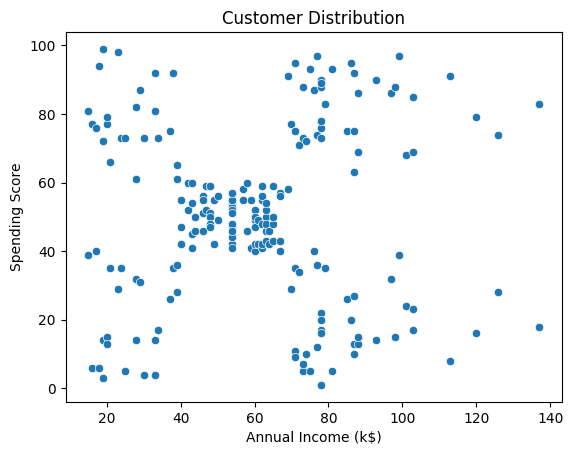

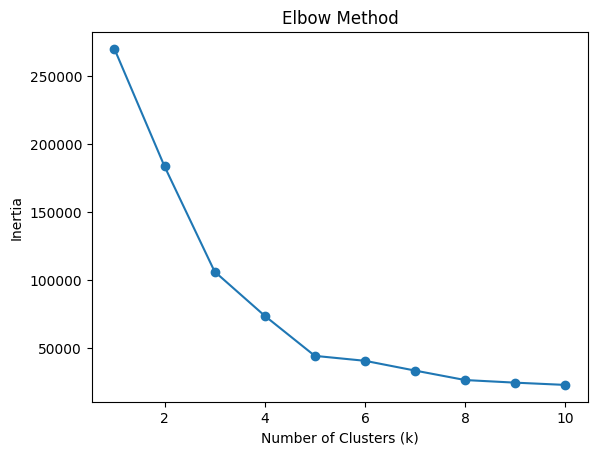

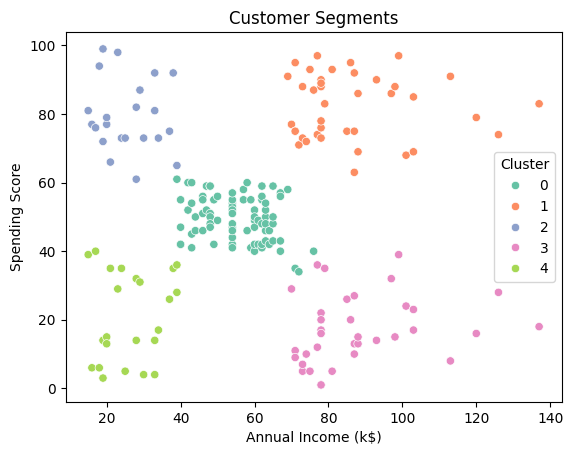


Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [1]:
# ============================================
# Cluster Analysis: Customer Segmentation
# ============================================

# --------------------------------------------
# Step 1: Import required libraries
# --------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

# --------------------------------------------
# Step 2: Load the dataset
# --------------------------------------------

df = pd.read_csv('Chapter_07-mall_customers.csv')

# --------------------------------------------
# Step 3: Explore the data
# --------------------------------------------
print("First five observations:")
print(df.head())

print("\nSummary statistics:")
print(df.describe())

# --------------------------------------------
# Step 4: Visualize the data
# --------------------------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title('Customer Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.show()

# --------------------------------------------
# Step 5: Determine number of clusters (Elbow Method)
# --------------------------------------------
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# --------------------------------------------
# Step 6: Apply K-means using chosen k
# --------------------------------------------
# Based on the elbow plot, students select k (typically k = 5)
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# --------------------------------------------
# Step 7: Visualize clusters
# --------------------------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

# --------------------------------------------
# Step 8: Examine cluster characteristics
# --------------------------------------------
print("\nCluster Summary:")
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())
